# Analysis and creating figures
This notebook contains the code for visualising findings.


In [4]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar
import plotly.express as px
import numpy as np
from math import ceil
import numpy as np
from scipy.stats import chi2_contingency


## Data Loading

Load the cleaned dataset (`cleaned_final_df.csv`) and ensure the date column is parsed correctly.

In [5]:
# import df
df = pd.read_csv('../final_df/cleaned_final_df.csv')
df.head()

,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,...,date_parsed,year,topic,probability,topic_norm,topic_label_nl,topic_meta_nl,topic_label,topic_meta,ai_words
0,Chatbot Emma glimlacht na een compliment Chatb...,Parool,2015-10-23,BART VAN ZOELEN,"'Dag Denise, hoe oud ben jij?"" vragen we Denis...",238,yes,['chatbot'],['chatbots'],"['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.153558,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
1,Vera en Roos hebben het druk Vera en Roos hebb...,Parool,2015-10-23,BART VAN ZOELEN,Klantenservice: Virtuele medewerkers kunnen st...,249,yes,[],"['chatbot', 'chatbots']","['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.212454,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
2,Leer van big data-incidenten Leer van big data...,Parool,2015-01-03,Unknown Authors,Keerpunt: De doorbraak van big data \nBracht 2...,303,yes,[],['slimme algoritmes'],['slimme algoritmes'],...,2015-01-03,2015,12,0.128177,12,bitcoin,BEDRIJF & FINANCIËN,bitcoin,BUSINESS & FINANCE,[]
3,Brieven Brieven,Parool,2015-09-03,Unknown Authors,Geen vrije keuze \nVrijdag had Het Parool een ...,310,yes,[],['algoritme'],['algoritme'],...,2015-09-03,2015,14,0.373948,14,onderwijs,ONDERWIJS,eductation,EDUCATION,[]
4,Stad van stenen en pixels Stad van stenen en p...,Parool,2015-05-19,TRACY METZ,"De talkshow Stadsleven, deze maand tegelijk me...",317,yes,[],['algoritme'],['algoritme'],...,2015-05-19,2015,8,1.000000,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]


In [6]:
# df.info()

In [7]:
# Make sure the column is datetime type
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Get the min and max
min_date = df['date'].min()
max_date = df['date'].max()

print("Earliest date:", min_date)
print("Latest date:", max_date)

Earliest date: 2015-01-01 00:00:00
Latest date: 2025-08-31 00:00:00


(Optionally filtering out date-outliers)

In [8]:
# # make sure 'date' is a datetime
# df['date'] = pd.to_datetime(df['date'], errors='coerce')

# # define your bounds
# start = pd.Timestamp("2015-01-01")
# end   = pd.Timestamp("2025-08-31")

# # filter rows outside the range
# mask = (df['date'] < start) | (df['date'] > end)

# # how many?
# n_outliers = mask.sum()
# print(f"Rows outside [2000–2024]: {n_outliers}")

# # inspect them
# outliers = df.loc[mask].copy()
# print(outliers[['title', 'outlet', 'date']].head(20))  # adjust columns to your needs

# # if you want to see distribution by year
# print(outliers['date'].dt.year.value_counts().sort_index())


## Descriptive Statistics

Basic counts and coverage checks: outlets in the dataset, articles per outlet, year range, and duplicate detection.

In [9]:
# ensure year is integer
df['year'] = df['year'].astype(int)

# A) Long (tidy) table: one row per (outlet, year)
counts_long = (
    df.groupby(['outlet', 'year'])
      .size()
      .rename('n')
      .reset_index()
      .sort_values(['outlet', 'year'])
)
counts_long
ranges = df.groupby('outlet')['year'].agg(year_min='min', year_max='max')

In [10]:
counts_long.to_excel('counts_outlets.xlsx')

In [11]:
#count exact-duplicate titles
rows_with_nonunique_titles = df['title'].duplicated(keep=False).sum()   # rows whose title repeats
rows_to_drop = df['title'].duplicated(keep='first').sum()               # rows that would be removed
print(rows_with_nonunique_titles, rows_to_drop)


0 0


In [12]:
#remove exact-duplicate titles (keep the first occurrence)
#df = df.drop_duplicates(subset=['title'], keep='first')


## Article Volume Over Time

How many AI-related articles were published per outlet per year? The combined plot gives an overview; the faceted version allows per-outlet comparison.

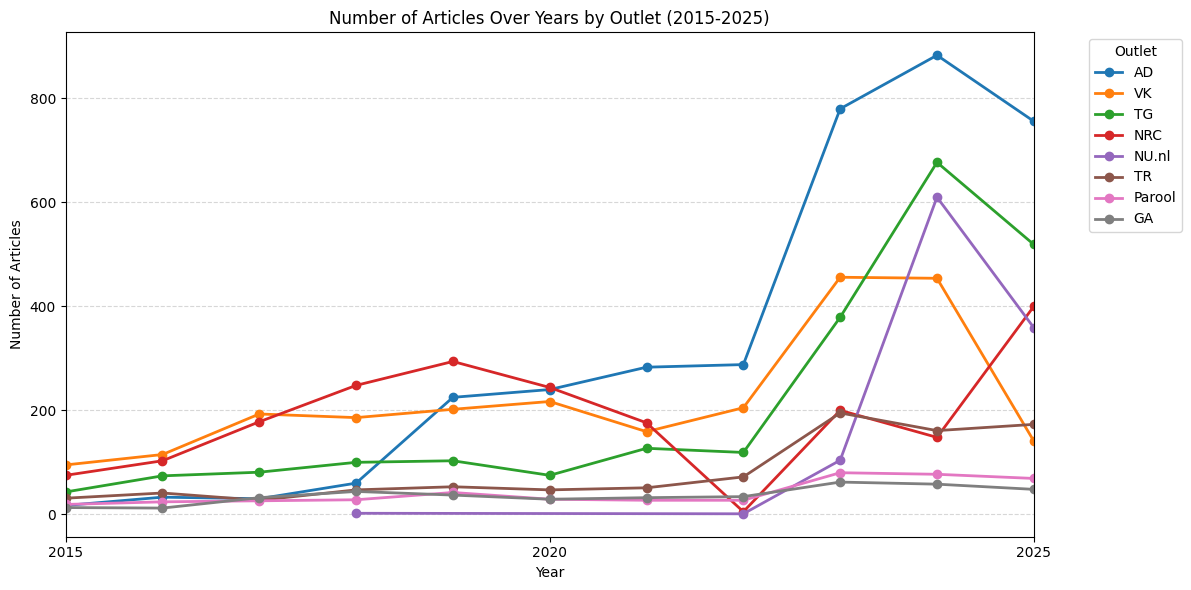

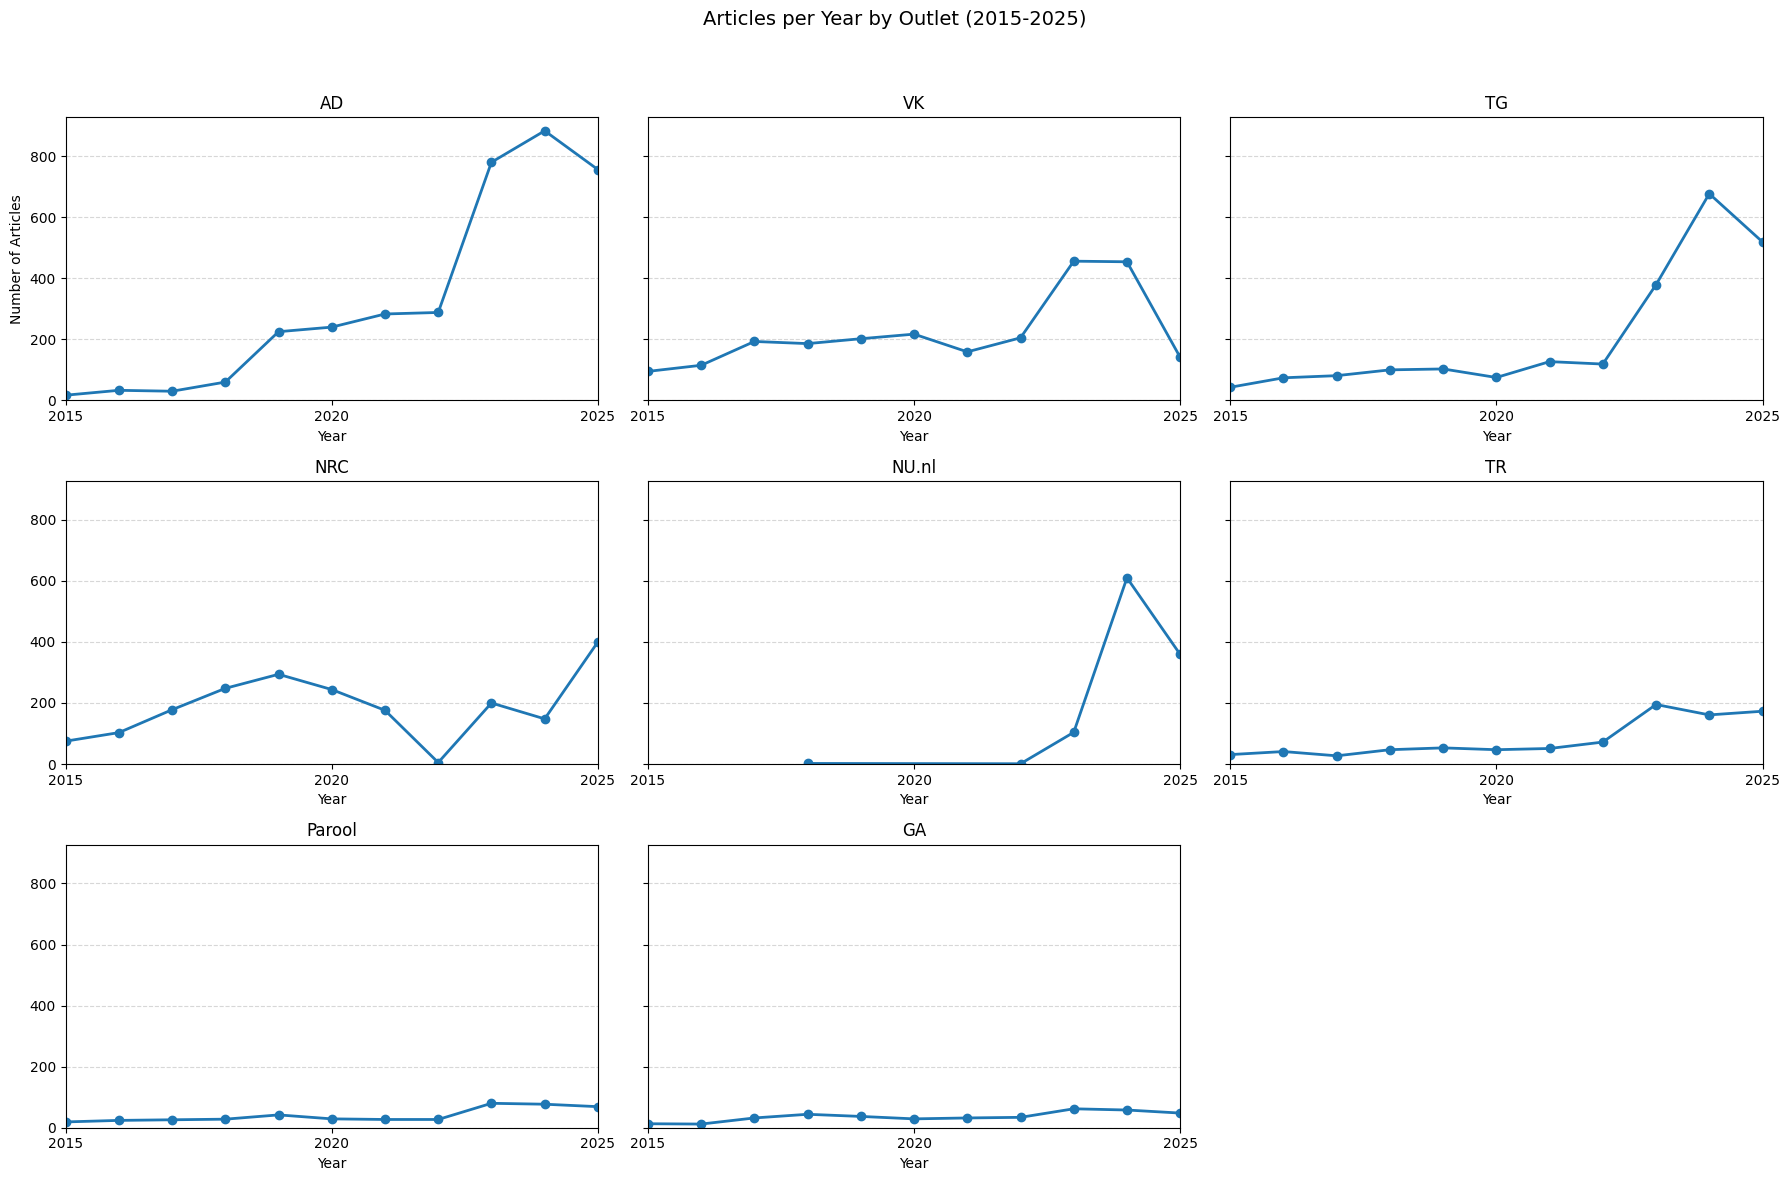

In [13]:
# ===== Config (tweak as needed) =====
TOP_OUTLETS   = None   # e.g. 6 to only show top-6 by volume; None = all
START_YEAR    = None   # e.g. 2000 to force a fixed start
END_YEAR      = None   # e.g. 2024 to force a fixed end
FIVE_YEAR_TICKS = True

# Prep
d = df[['outlet','year']].dropna().copy()
d['year'] = d['year'].astype(int)

# Count the number of articles per outlet per year
articles_per_year = (
    d.groupby(['outlet','year'])
     .size()
     .reset_index(name='count')
     .sort_values(['outlet','year'])
)

# Which outlets (optionally top-N by total volume)?
totals = articles_per_year.groupby('outlet')['count'].sum().sort_values(ascending=False)
outlets = totals.index.tolist() if TOP_OUTLETS is None else totals.head(TOP_OUTLETS).index.tolist()

# Year range (auto unless overridden)
yr_min = int(articles_per_year['year'].min()) if START_YEAR is None else int(START_YEAR)
yr_max = int(articles_per_year['year'].max()) if END_YEAR   is None else int(END_YEAR)

def five_year_ticks(start, end):
    start5 = (start // 5) * 5
    step   = 5 if (end - start) >= 5 else 1
    return np.arange(start5, end + 1, step)

# =========================
# 1) Combined plot (all outlets)
# =========================
plt.figure(figsize=(12, 6))
for outlet in outlets:
    od = articles_per_year[articles_per_year['outlet'] == outlet]
    plt.plot(od['year'], od['count'], marker='o', linewidth=2, label=outlet)

plt.xlim(yr_min, yr_max)
if FIVE_YEAR_TICKS:
    plt.xticks(five_year_ticks(yr_min, yr_max))
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title(f'Number of Articles Over Years by Outlet ({yr_min}-{yr_max})')
plt.legend(title='Outlet', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================
# 2) Facet: one graph per outlet
# =========================
n = len(outlets)
ncols = 3 if n >= 3 else n
nrows = ceil(n / ncols) if n else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

# consistent y-limit for comparability
global_ymax = articles_per_year['count'].max()

for ax, outlet in zip(axes, outlets):
    od = articles_per_year[articles_per_year['outlet'] == outlet].copy()
    ax.plot(od['year'], od['count'], marker='o', linewidth=2)

    ax.set_xlim(yr_min, yr_max)
    if FIVE_YEAR_TICKS:
        ax.set_xticks(five_year_ticks(yr_min, yr_max))
    ax.set_ylim(0, global_ymax * 1.05)

    ax.set_title(outlet)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('Year')

# tidy layout
for j in range(len(outlets), len(axes)):
    axes[j].axis('off')
axes[0].set_ylabel('Number of Articles')

fig.suptitle(f'Articles per Year by Outlet ({yr_min}-{yr_max})', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [14]:
counts_wide = pd.crosstab(df['outlet'], df['year'])
# with totals:
# counts_wide = pd.crosstab(df['news_brand'], df['year'], margins=True, margins_name='Total')
counts_wide


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
outlet,,,,,,,,,,,
AD,17,33,30,60,225,240,283,288,780,883,756
GA,13,12,32,44,37,29,32,34,62,58,48
NRC,75,103,178,248,294,244,176,5,200,148,400
NU.nl,0,0,0,2,0,0,0,1,104,610,359
Parool,19,24,26,28,42,29,27,27,80,77,69
TG,43,74,81,100,103,75,127,119,379,677,519
TR,31,41,27,47,53,47,51,72,195,161,173
VK,95,115,193,186,202,217,159,205,456,454,141


In [15]:
#proportion of migration articles vs total
counts = pd.read_excel('total_articles_clean2.xlsx')
counts

,Year,AD,Volkskrant,Telegraaf,Trouw
0,2000,38737,32743,16640,34181
1,2001,35629,35071,16610,31740
2,2002,33042,35566,27652,30763
3,2003,35400,35019,29549,28908
4,2004,44066,37278,41368,31442
5,2005,42292,35685,44933,32363
6,2006,38584,41139,45536,33616
7,2007,38354,42123,46627,32077
8,2008,35692,38189,46012,31620
9,2009,37916,36605,44708,31460


## AI Coverage as Proportion of Total Articles

Raw article counts can be misleading if some outlets publish far more in total. Here we divide the number of AI-related articles by the total articles published per outlet per year to get a comparable share.

> **Note:** Total article data is only available for AD, Volkskrant, Telegraaf, and Trouw. Other outlets are excluded from this analysis.

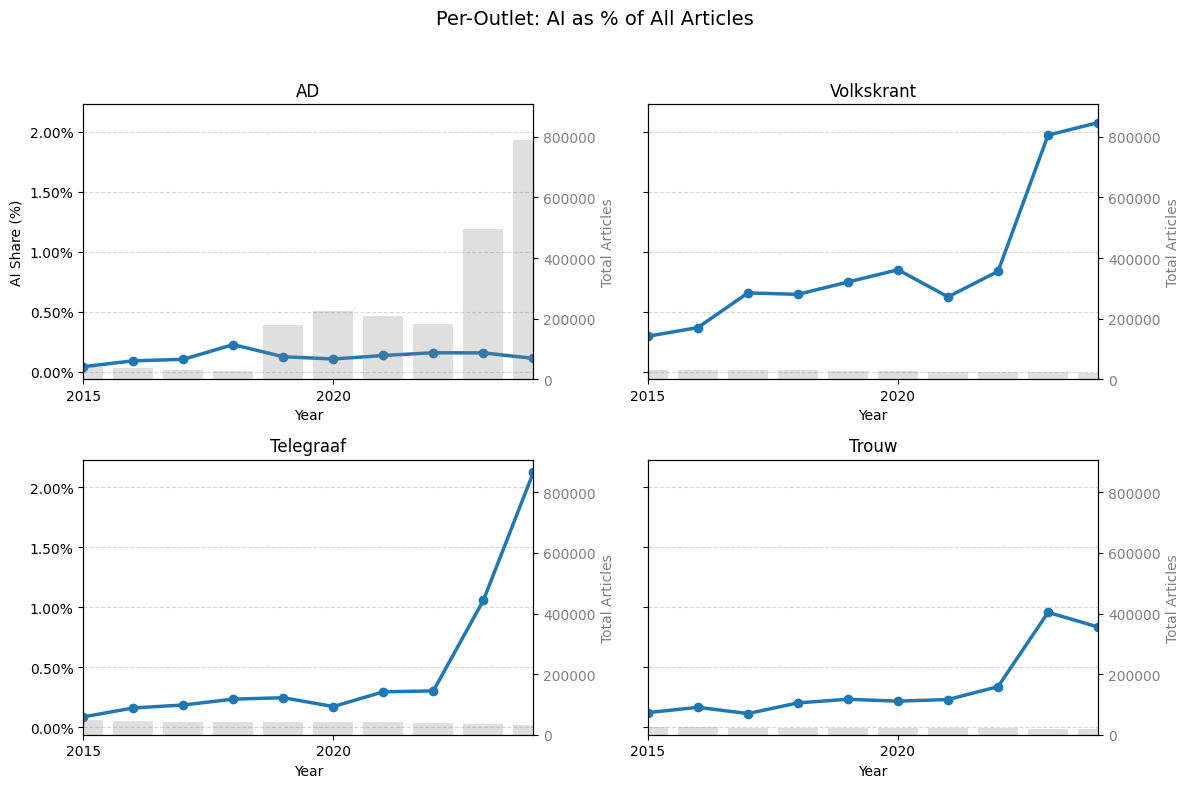

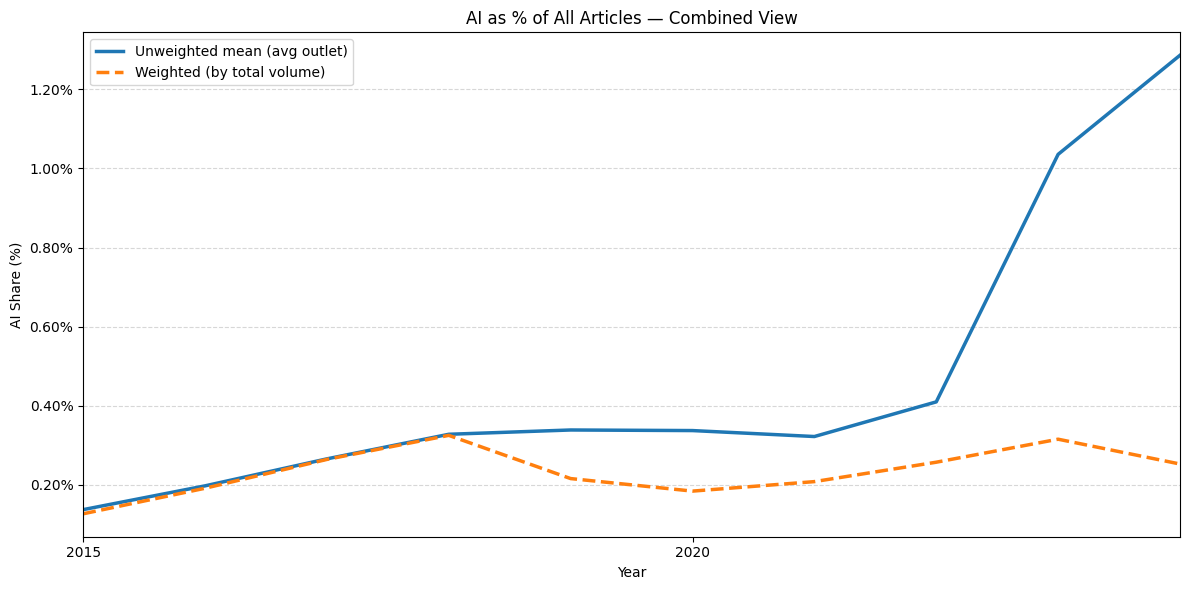

In [16]:
# =========================
# CONFIG
# =========================
MIN_TOTAL_PER_OUTLET_YEAR = 30     # filter very small denominators
FIVE_YEAR_TICKS = True

# Map your df['news_brand'] to the column names used in `counts`
# Extend if you have other spellings.
BRAND_MAP = {
    'AD': 'AD', 'Algemeen Dagblad': 'AD',
    'VK': 'Volkskrant', 'de Volkskrant': 'Volkskrant', 'Volkskrant': 'Volkskrant',
    'TG': 'Telegraaf', 'De Telegraaf': 'Telegraaf', 'Telegraaf': 'Telegraaf',
    'TR': 'Trouw', 'Trouw': 'Trouw'
}

# =========================
# 1) Prepare migration-only df (your df)
# =========================
df_mig = df[['outlet', 'year']].dropna().copy()
df_mig['year'] = df_mig['year'].astype(int)
df_mig['brand_counts_name'] = df_mig['outlet'].map(BRAND_MAP)

# keep rows that we can map to counts columns
valid_brands = ['AD', 'Volkskrant', 'Telegraaf', 'Trouw']
df_mig = df_mig[df_mig['brand_counts_name'].isin(valid_brands)]

# migration counts per outlet-year
mig_by = (
    df_mig.groupby(['brand_counts_name', 'year'])
          .size()
          .rename('mig_n')
          .reset_index()
)

# =========================
# 2) Prepare `counts` (wide → long)
# =========================
c = counts.rename(columns={'Year': 'year'}).copy()
c['year'] = c['year'].astype(int)

counts_long = c.melt(
    id_vars='year',
    value_vars=valid_brands,
    var_name='brand_counts_name',
    value_name='total_n'
).dropna()

counts_long['total_n'] = counts_long['total_n'].astype(int)

# restrict to overlapping years just in case
min_year = max(int(df_mig['year'].min()), int(counts_long['year'].min()))
max_year = min(int(df_mig['year'].max()), int(counts_long['year'].max()))
counts_long = counts_long[(counts_long['year'] >= min_year) & (counts_long['year'] <= max_year)]
mig_by = mig_by[(mig_by['year'] >= min_year) & (mig_by['year'] <= max_year)]

# =========================
# 3) Merge & compute percentages
# =========================
merged = counts_long.merge(mig_by, on=['brand_counts_name', 'year'], how='left')
merged['mig_n'] = merged['mig_n'].fillna(0).astype(int)

# filter low-volume outlet-years
merged = merged[merged['total_n'] >= MIN_TOTAL_PER_OUTLET_YEAR].copy()

# % migration of all articles
merged['pct_mig'] = 100.0 * merged['mig_n'] / merged['total_n']

# Helper: 5-year ticks
def five_year_ticks(years):
    years = pd.Index(years).astype(int)
    mn, mx = years.min(), years.max()
    start = (mn // 5) * 5
    return np.arange(start, mx + 1, 5 if (mx - mn) >= 5 else 1)

# =========================
# 4) Per-outlet facets (line = %, bars = total)
# =========================
brands = valid_brands
yr_min, yr_max = int(merged['year'].min()), int(merged['year'].max())

n = len(brands)
ncols = 2 if n <= 4 else 3
nrows = ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

global_ymax_total = merged['total_n'].max()

for ax, brand in zip(axes, brands):
    sub = merged[merged['brand_counts_name'] == brand].copy()
    # right y-axis: total articles
    ax2 = ax.twinx()
    ax2.bar(sub['year'], sub['total_n'], color='grey', alpha=0.25, width=0.8)
    ax2.set_ylabel('Total Articles', color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.set_ylim(0, max(global_ymax_total * 1.15, 10))

    # left y-axis: % migration
    ax.plot(sub['year'], sub['pct_mig'], marker='o', linewidth=2.5)
    ax.set_xlim(yr_min, yr_max)
    if FIVE_YEAR_TICKS: ax.set_xticks(five_year_ticks(sub['year']))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(brand)
    ax.set_xlabel('Year')

# tidy facet grid
for j in range(len(brands), len(axes)):
    axes[j].axis('off')
axes[0].set_ylabel('AI Share (%)')
fig.suptitle('Per-Outlet: AI as % of All Articles', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =========================
# 5) Combined plot: unweighted vs weighted
# =========================
# Unweighted = average of outlet-year % (each outlet contributes equally)
pct_unweighted = (
    merged.groupby('year')['pct_mig']
          .mean()
          .rename('unweighted_mean_%')
          .to_frame()
)

# Weighted = total migration / total articles (volume matters)
year_totals = merged.groupby('year')['total_n'].sum()
year_mig    = merged.groupby('year')['mig_n'].sum()
pct_weighted = (100.0 * year_mig / year_totals).rename('weighted_%').to_frame()

combined = pct_unweighted.join(pct_weighted, how='outer').sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(combined.index, combined['unweighted_mean_%'], label='Unweighted mean (avg outlet)', linewidth=2.5)
ax.plot(combined.index, combined['weighted_%'],        label='Weighted (by total volume)', linewidth=2.5, linestyle='--')
ax.set_xlim(combined.index.min(), combined.index.max())
if FIVE_YEAR_TICKS: ax.set_xticks(five_year_ticks(combined.index))
ax.set_xlabel('Year')
ax.set_ylabel('AI Share (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_title('AI as % of All Articles — Combined View')
ax.legend()
plt.tight_layout()
plt.show()

# =========================
# 6) (Optional) handy tables
# =========================
summary_long = merged[['brand_counts_name', 'year', 'mig_n', 'total_n', 'pct_mig']].sort_values(['brand_counts_name','year'])
summary_wide_pct = summary_long.pivot(index='brand_counts_name', columns='year', values='pct_mig').sort_index()
# summary_long.to_csv('migration_share_per_outlet_year.csv', index=False)
# summary_wide_pct.to_csv('migration_share_pct_wide.csv')


## Topic Distribution per Outlet

Stacked bar charts showing what share of each outlet's AI-related articles falls into each meta-topic category (normalised to 100%).

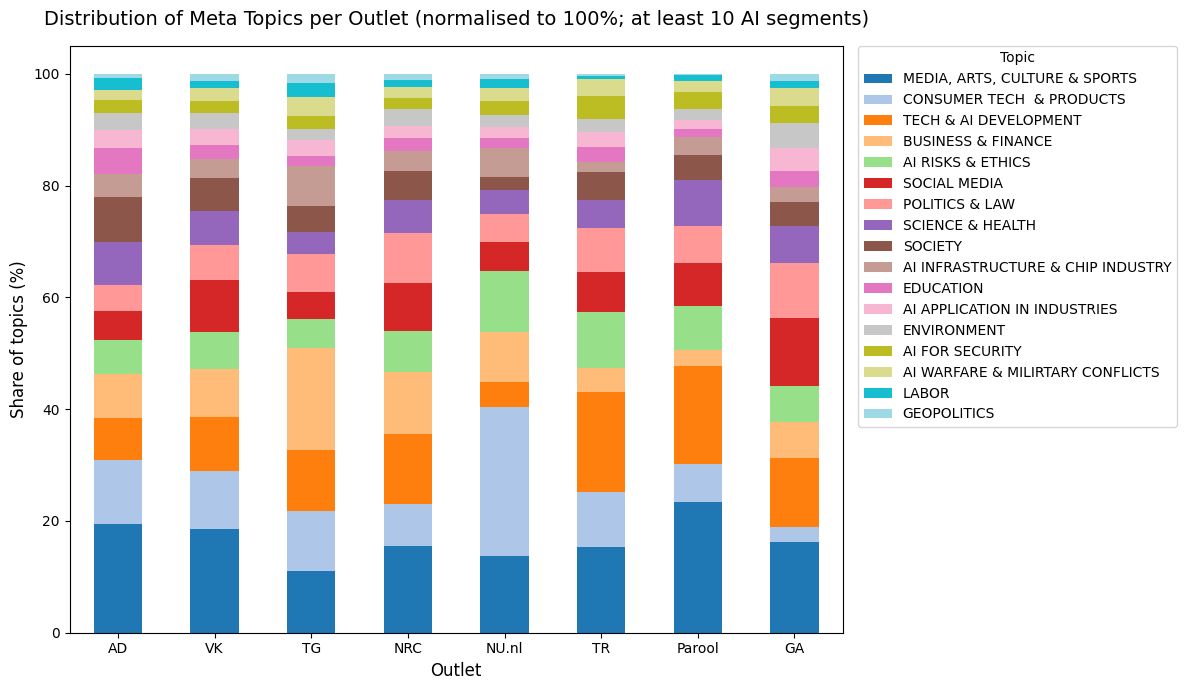

In [32]:
# =========================
# CONFIG
# =========================
BRAND_COL = "outlet"
TOPIC_COL = "topic_meta"

MIN_TOTAL_PER_BRAND = 10    # optional: filter out brands with very few articles
FIGSIZE = (12, 7)
ROT_X = 0                   # rotation of x-axis labels (0, 45, etc.)

# =========================
# 1) Prepare data
# =========================
# Drop missing values
df_plot = df[[BRAND_COL, TOPIC_COL]].dropna(subset=[BRAND_COL, TOPIC_COL])

# Create contingency table: counts of topics per news brand
ct = (
    df_plot
    .groupby([BRAND_COL, TOPIC_COL])
    .size()
    .unstack(fill_value=0)
)

# Filter out small brands (optional)
brand_totals = ct.sum(axis=1)
ct = ct.loc[brand_totals >= MIN_TOTAL_PER_BRAND]

# Sort topics by total frequency (for nicer order in legend)
topic_order = ct.sum(axis=0).sort_values(ascending=False).index
ct = ct[topic_order]

# Sort brands by total number of articles
brand_order = ct.sum(axis=1).sort_values(ascending=False).index
ct = ct.loc[brand_order]

# =========================
# 2) Normalise to percentages
# =========================
ct_percent = ct.div(ct.sum(axis=1), axis=0).replace([np.inf, np.nan], 0.0) * 100

# =========================
# 3) Plot
# =========================
ax = ct_percent.plot(
    kind="bar",
    stacked=True,
    figsize=FIGSIZE,
    cmap="tab20"   # nice diverse colour map
)

# Labeling and formatting
ax.set_xlabel("Outlet", fontsize=12)
ax.set_ylabel("Share of topics (%)", fontsize=12)
ax.set_title("Distribution of Meta Topics per Outlet (normalised to 100%; at least 10 AI segments)", fontsize=14, pad=15)
ax.tick_params(axis="x", labelrotation=ROT_X)

# Legend on the side for readability
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()


In [18]:
# Ensure 'created_at' is in datetime format
#df['created_at'] = pd.to_datetime(df['created_at'])

# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['outlet', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='outlet', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Identify the most significant meta topics per country
residuals = (contingency_table - ex) / ex**0.5

# Find the most significant residuals
significant_residuals = residuals.unstack().sort_values(ascending=False)

# Display results
print(f"Chi-squared Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies Table: \n{ex}")

# Display the top 10 most significant residuals
print("Top 10 most significant residuals:")

Chi-squared Statistic: 1294.3893692906536
P-value: 2.942140511128334e-200
Degrees of Freedom: 112
Expected Frequencies Table: 
[[ 97.35278072  87.83505077 153.64335505 249.09258979  84.02795878
  356.77890589 403.00787998 103.33535384  97.08084558  38.88672526
   60.36960145 591.73086831 230.32906501 215.10069708 247.18904379
  205.85490226 367.38437642]
 [ 10.87725413   9.81383543  17.16661615  27.83118654   9.38846795
   39.86300955  45.02818609  11.54568874  10.84687074   4.34482497
    6.7451129   66.11425974  25.73473254  24.03326262  27.6185028
   23.00022731  41.04796181]
 [ 56.12229126  50.63547507  88.57288983 143.59781785  48.4407486
  205.67722382 232.32747386  59.57114714  55.96552508  22.41756327
   34.80209123 341.12320048 132.78095166 124.00204576 142.50045461
  118.67199576 211.79110471]
 [ 29.18684649  26.33338385  46.06303985  74.67919382  25.19199879
  106.96408547 120.82376118  30.98045158  29.10531899  11.6584331
   18.09910593 177.40384907  69.05379603  64.4882558

In [19]:
# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['outlet', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='outlet', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Calculate residuals
residuals = (contingency_table - ex) / ex**0.5

# Flatten the residuals DataFrame and sort by residual values
significant_residuals = residuals.unstack().sort_values(ascending=False).reset_index()
significant_residuals.columns = ['Meta', 'outlet', 'Residual']

# Display the top 10 most significant residuals in a table
top_10_residuals = significant_residuals.head(10)
print(top_10_residuals)

                                Meta  outlet   Residual
0          CONSUMER TECH  & PRODUCTS   NU.nl  15.208920
1                BUSINESS & FINANCE       TG  12.484777
2              TECH & AI DEVELOPMENT      TR   7.204810
3  AI INFRASTRUCTURE & CHIP INDUSTRY      TG   6.420378
4                            SOCIETY      AD   5.934430
5                          EDUCATION      AD   5.869385
6                  AI RISKS & ETHICS   NU.nl   5.012989
7              TECH & AI DEVELOPMENT  Parool   4.893866
8                    POLITICS & LAW      NRC   4.618482
9                       SOCIAL MEDIA      VK   4.517699


## Most Distinctive Topics per Outlet (Chi-Square Analysis)

To identify which meta-topics are *over-* or *under-represented* per outlet relative to what would be expected by chance, we run a chi-square test of independence on the outlet × topic contingency table and inspect the standardised residuals.

A large positive residual means an outlet covers that topic significantly more than average; a large negative residual means significantly less.

In [20]:
BRAND_COL = "outlet"
TOPIC_COL = "topic_meta"
TOP_N = 10

# 1) Contingency table (brands × topics)
aggregated_meta = (
    df.groupby([BRAND_COL, TOPIC_COL])
      .size()
      .reset_index(name='count')
)

contingency = (
    aggregated_meta
    .pivot(index=BRAND_COL, columns=TOPIC_COL, values='count')
    .fillna(0)
    .astype(int)
)

# Drop brands/topics that are all zero (safeguard)
contingency = contingency.loc[contingency.sum(axis=1) > 0, contingency.sum(axis=0) > 0]

if contingency.empty or contingency.shape[0] < 2 or contingency.shape[1] < 2:
    raise ValueError("Not enough non-empty rows/cols to run chi-square.")

# 2) Chi-square on counts
chi2, p, dof, expected = chi2_contingency(contingency.values, correction=False)

# Wrap expected as DataFrame aligned to contingency
ex_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

# 3) Standardized residuals
# Guard: avoid divide-by-zero if any expected cell is (near) zero
den = np.sqrt(ex_df.replace(0, np.nan))
residuals = (contingency - ex_df) / den

# 4) Tidy long format (consistent column names!)
residuals_flat = (
    residuals.stack()
             .rename("Residual")
             .reset_index()
             .rename(columns={BRAND_COL: "news_brand", TOPIC_COL: "topic_meta"})
)

# 5) Split + take top/bottom per brand
positive = residuals_flat[residuals_flat["Residual"] > 0].copy()
negative = residuals_flat[residuals_flat["Residual"] < 0].copy()

def top_per_brand(df_in, n=TOP_N, ascending=False):
    return (df_in.sort_values(["news_brand", "Residual"], ascending=[True, ascending])
                 .groupby("news_brand", as_index=False)
                 .head(n))

top_pos = top_per_brand(positive, n=TOP_N, ascending=False)
top_neg = top_per_brand(negative, n=TOP_N, ascending=True)

# 6) Build summary dicts (brand → list of topics)
most_distinct = (top_pos.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())
least_distinct = (top_neg.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())

# 7) Assemble display table
brands_order = list(contingency.index)  # keep contingency row order
table_df = pd.DataFrame({
    "News Brand": brands_order,
    "Most Distinct Topics": [", ".join(most_distinct.get(b, [])) for b in brands_order],
    "Least Distinct Topics": [", ".join(least_distinct.get(b, [])) for b in brands_order],
})

print(table_df)

# 8) APA-style line
chi2_apa = f"χ²({dof}) = {chi2:.2f}, p < .001" if p < 0.001 else f"χ²({dof}) = {chi2:.2f}, p = {p:.3f}"
print("\nChi-squared Test Result (APA Style):")
print(chi2_apa)


  News Brand                               Most Distinct Topics  \
0         AD  SOCIETY, EDUCATION, MEDIA, ARTS, CULTURE & SPO...   
1         GA  SOCIAL MEDIA, POLITICS & LAW , ENVIRONMENT, AI...   
2        NRC  POLITICS & LAW , TECH & AI DEVELOPMENT, SOCIAL...   
3      NU.nl  CONSUMER TECH  & PRODUCTS, AI RISKS & ETHICS, ...   
4     Parool  TECH & AI DEVELOPMENT, MEDIA, ARTS, CULTURE & ...   
5         TG  BUSINESS & FINANCE , AI INFRASTRUCTURE & CHIP ...   
6         TR  TECH & AI DEVELOPMENT, AI RISKS & ETHICS, AI F...   
7         VK  SOCIAL MEDIA, MEDIA, ARTS, CULTURE & SPORTS, G...   

                               Least Distinct Topics  
0  TECH & AI DEVELOPMENT, POLITICS & LAW , BUSINE...  
1  CONSUMER TECH  & PRODUCTS, BUSINESS & FINANCE ...  
2  CONSUMER TECH  & PRODUCTS, AI APPLICATION IN I...  
3  TECH & AI DEVELOPMENT, SOCIETY, SCIENCE & HEAL...  
4  BUSINESS & FINANCE , CONSUMER TECH  & PRODUCTS...  
5  MEDIA, ARTS, CULTURE & SPORTS, SCIENCE & HEALT...  
6  BUSINESS

In [21]:
table_df.to_excel('distinct_topics.xlsx')

In [22]:
df['year'].value_counts()

year
2024    3068
2025    2465
2023    2256
2019     956
2020     881
2021     855
2022     751
2018     715
2017     567
2016     402
2015     293
Name: count, dtype: int64

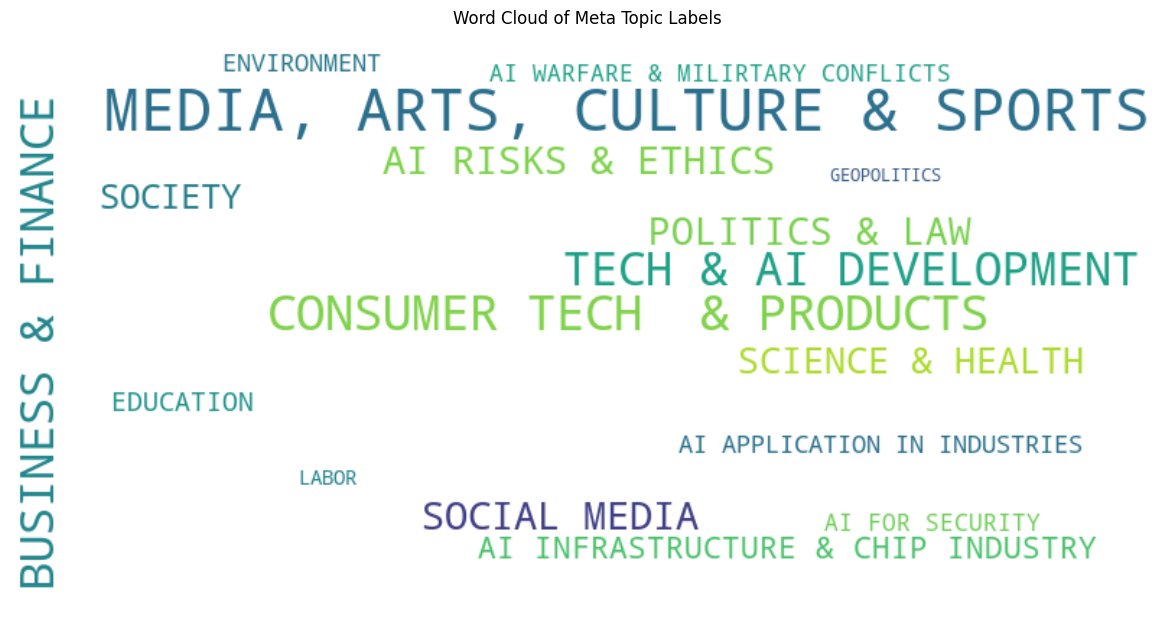

In [23]:
#word cloud meta topics
from wordcloud import WordCloud

# 2) Compute frequencies of each label
label_counts = df['topic_meta'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Meta Topic Labels')
plt.show()


In [24]:
# amount of different topics
print("Number of unique topics:", df['topic_meta'].nunique())

Number of unique topics: 17


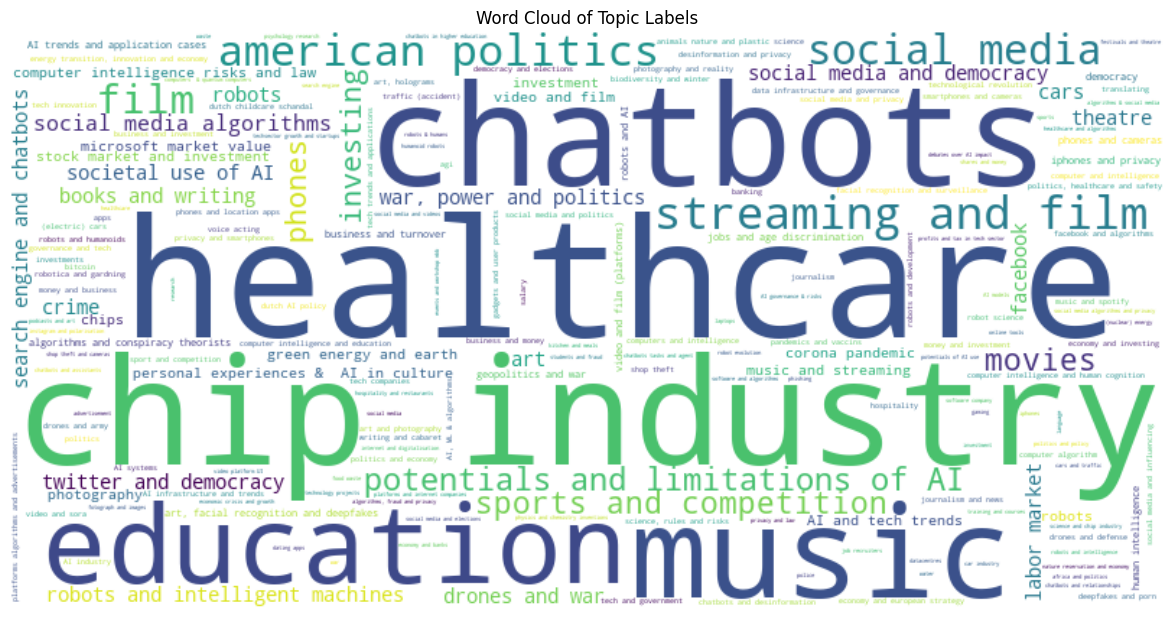

In [25]:
#word cloud labels

# 2) Compute frequencies of each label
label_counts = df['topic_label'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topic Labels')
plt.show()


## Topic Visualisations

Word clouds and bar charts summarising the overall distribution of meta-topics and sub-topic labels across the full dataset.

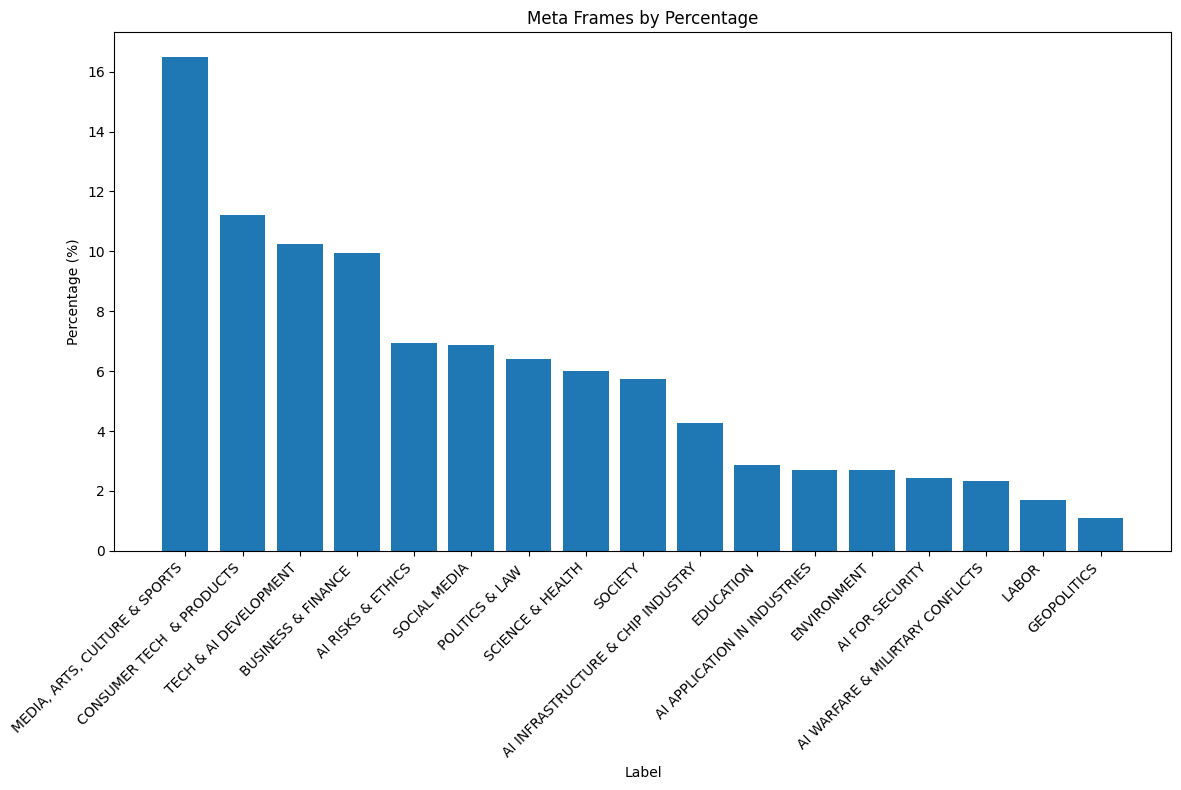

In [26]:
# Overview macro topics (percentages instead of raw counts)
meta_percent = df['topic_meta'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 8))
plt.bar(meta_percent.index, meta_percent.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title('Meta Frames by Percentage')
plt.tight_layout()
plt.show()


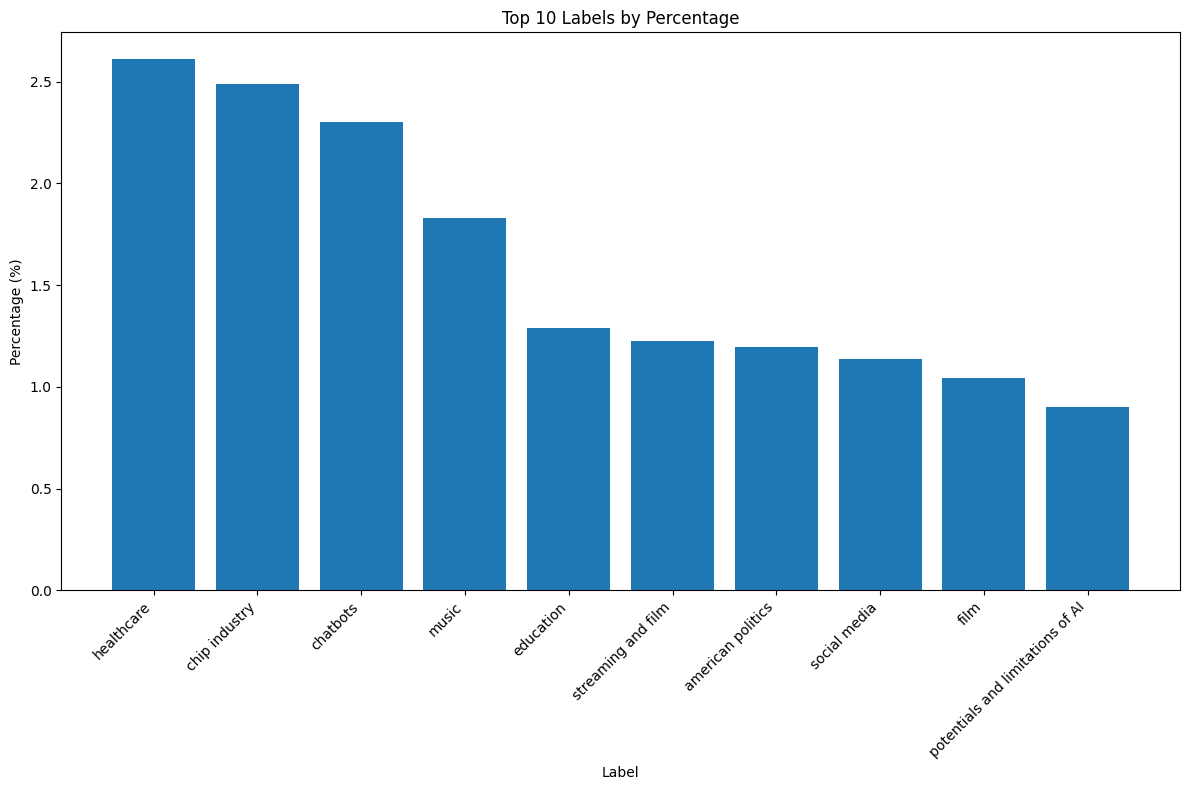

In [27]:
# Set how many top labels you want to display
top_n = 10   # ← change this to whatever you need

# Compute percentages
label_percent = df['topic_label'].value_counts(normalize=True) * 100

# Keep only the top X
label_percent_top = label_percent.head(top_n)

plt.figure(figsize=(12, 8))
plt.bar(label_percent_top.index, label_percent_top.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title(f'Top {top_n} Labels by Percentage')
plt.tight_layout()
plt.show()


## Topic Distribution per Year

Each subplot shows the top-N meta-topics (as % of all articles that year), making it easy to compare how the topic mix shifts year by year.

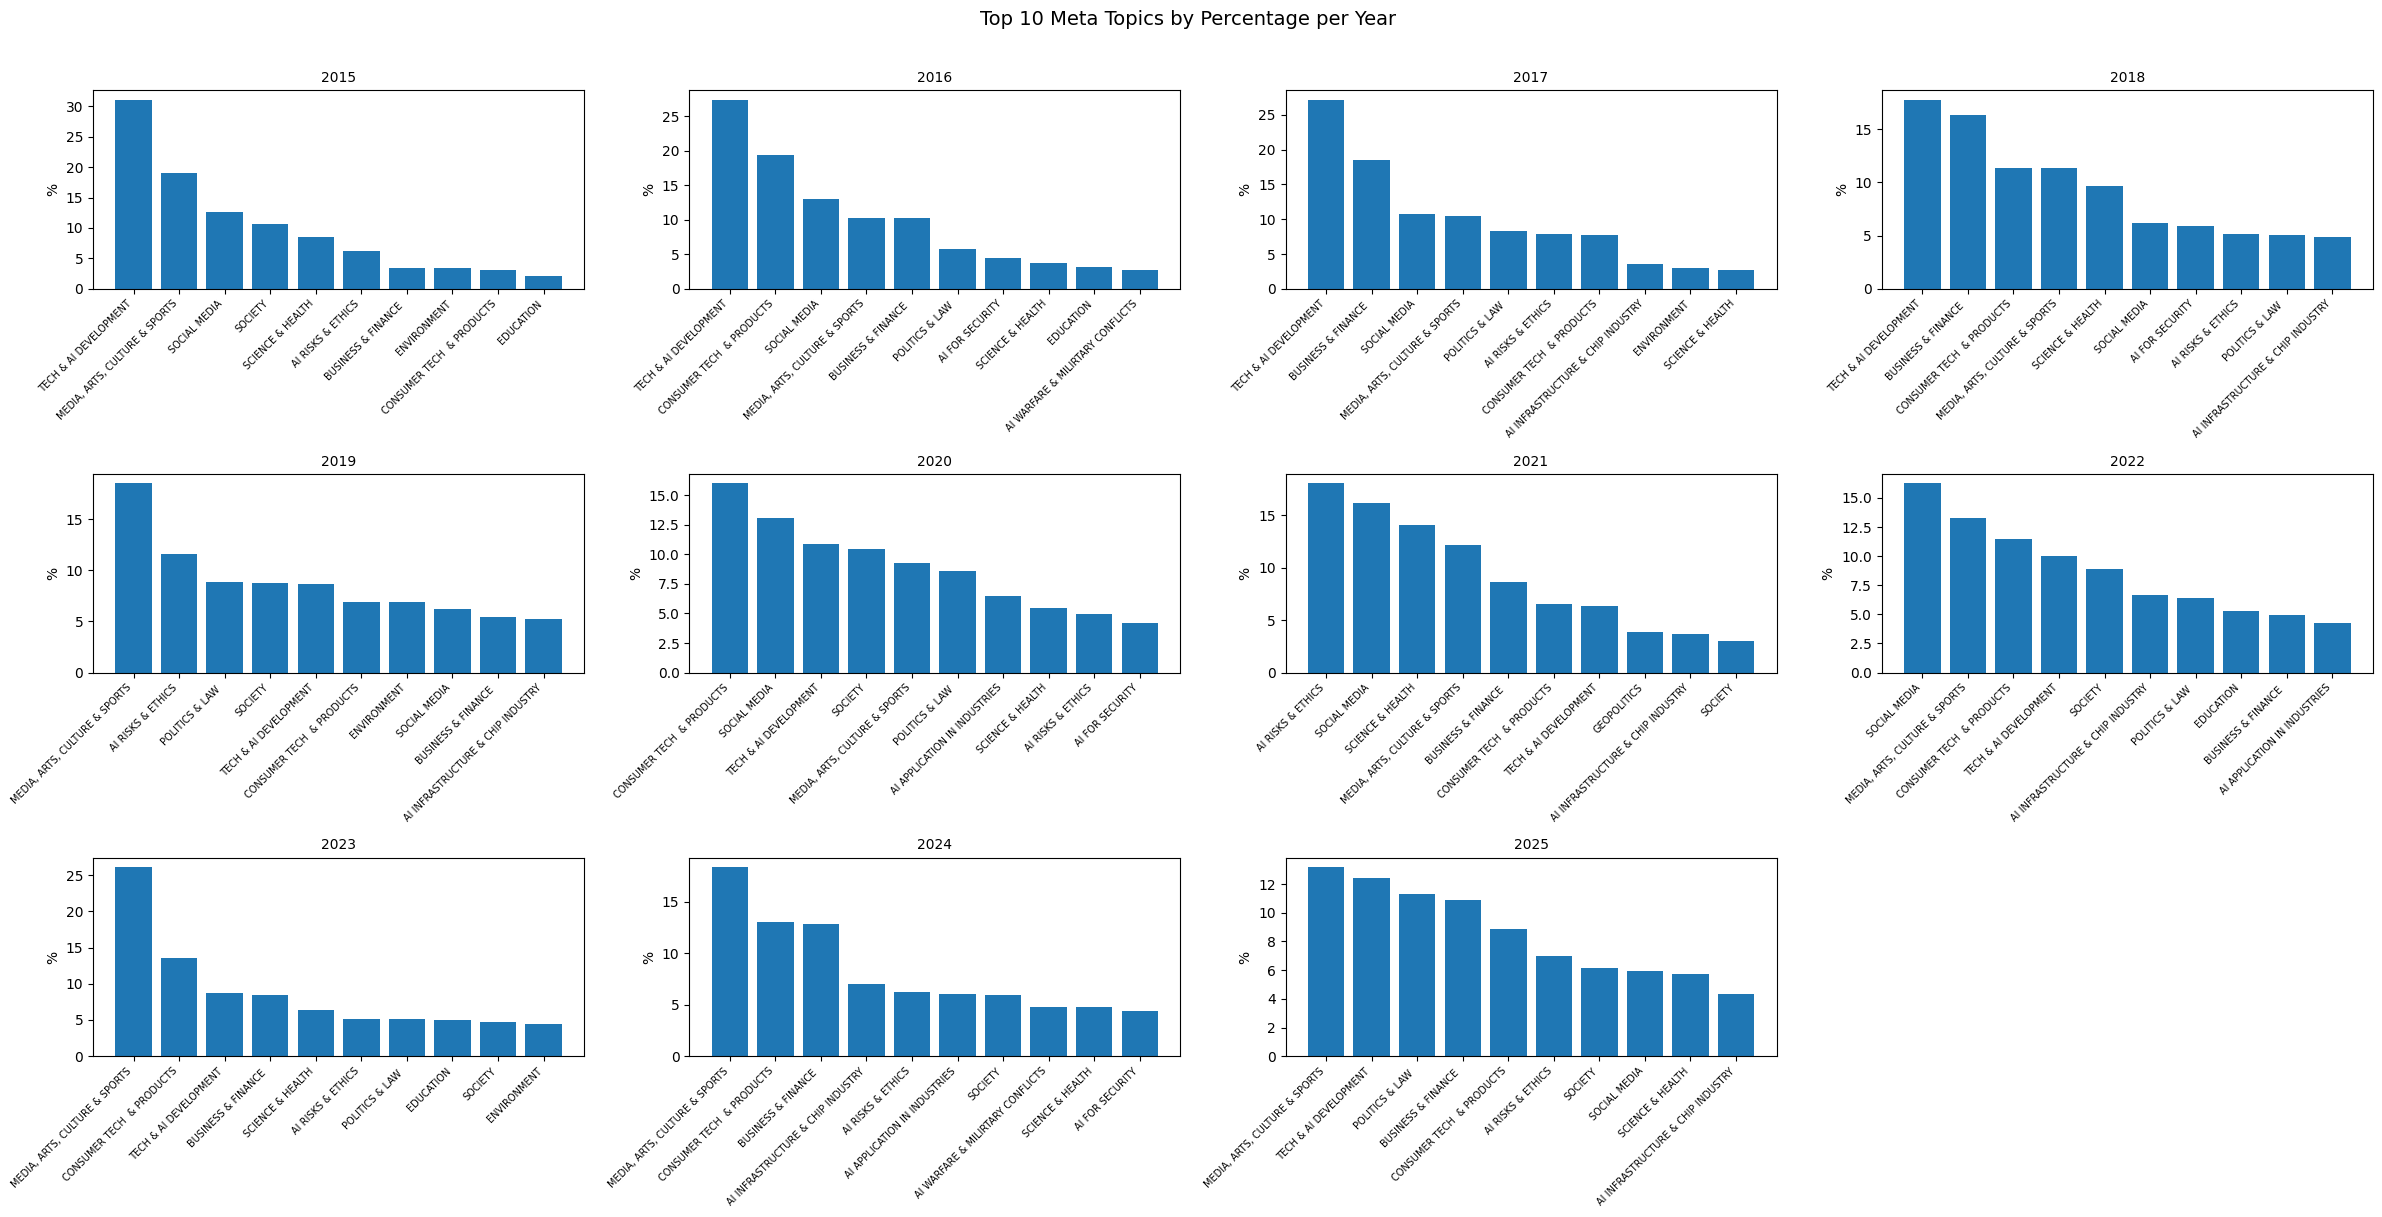

In [28]:
#Bar chart per year - adjust to macro, meta or label
top_n = 10  # number of labels to display per year
label = 'Meta'  #'Macro' #'Meta' #'Label'

years = sorted(df['year'].unique())

ncols = 4
nrows = ceil(len(years) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, yr in zip(axes, years):
    df_year = df[df['year'] == yr]
    label_percent_top = (
        df_year['topic_meta']
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=False)
        .head(top_n)
    )
    ax.bar(range(len(label_percent_top)), label_percent_top.values)
    ax.set_xticks(range(len(label_percent_top)))
    ax.set_xticklabels(label_percent_top.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(str(yr), fontsize=10)
    ax.set_ylabel('%')

for j in range(len(years), len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Top {top_n} {label} Topics by Percentage per Year', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Topic Trends Over Time

Line charts showing how the share of each meta-topic evolves across the full time period (2015–2025). The highlighted version draws attention to the five most frequent topics while graying out the rest.

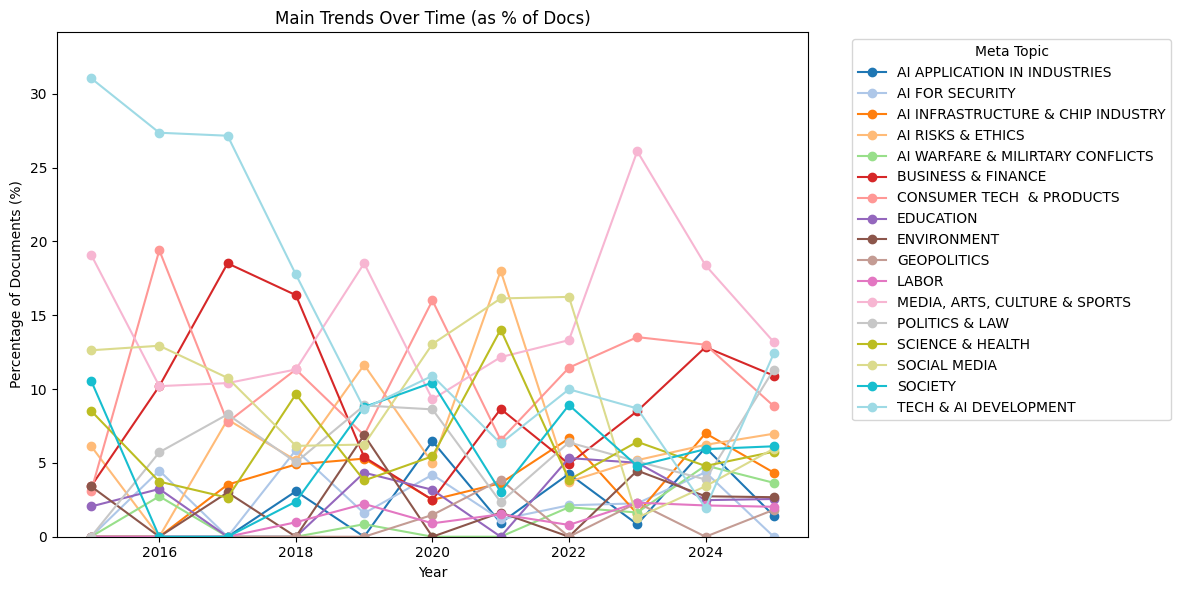

In [29]:
# 1. Build counts per year × meta-topic
counts = (
    df
    .groupby(['year', 'topic_meta'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. Convert to percentages per year
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# 3. Pick a qualitative colormap with exactly as many bins as you have topics
n_topics = pct.shape[1]
cmap = plt.get_cmap('tab20', n_topics)   # swap in 'tab20b', 'gist_ncar', etc. if you exceed 20
colors = cmap(np.arange(n_topics))

# 4. Plot each line
plt.figure(figsize=(12, 6))
for color, topic in zip(colors, pct.columns):
    plt.plot(
        pct.index,          # x = year
        pct[topic],         # y = % share
        marker='o',
        label=topic,
        color=color
    )

# 5. Tidy up
plt.xlabel('Year')
plt.ylabel('Percentage of Documents (%)')
plt.title('Main Trends Over Time (as % of Docs)')
plt.ylim(0, pct.values.max() * 1.1)  # add some headroom
plt.legend(
    title='Meta Topic',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


In [30]:
# pick the top X most frequent
meta_counts = df['topic_meta'].value_counts()
toptopics = meta_counts.head(5).index.tolist()
toptopics

['MEDIA, ARTS, CULTURE & SPORTS',
 'CONSUMER TECH  & PRODUCTS',
 'TECH & AI DEVELOPMENT',
 'BUSINESS & FINANCE ',
 'AI RISKS & ETHICS']

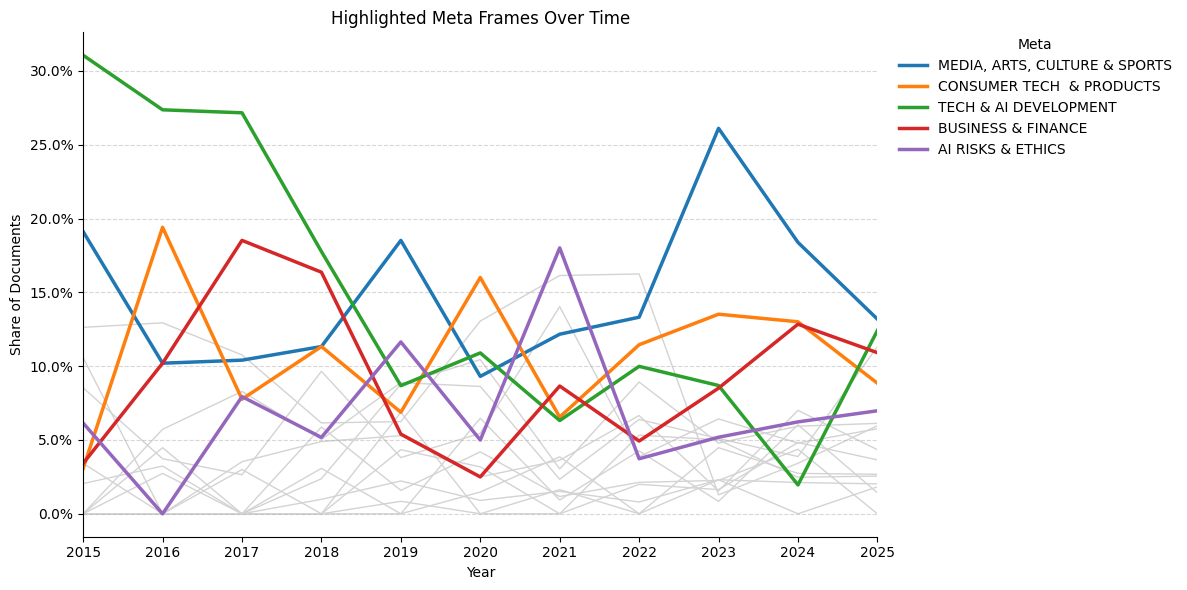

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

# plot all lines in light grey
for col in pct.columns:
    ax.plot(pct.index, pct[col], color='lightgrey', linewidth=1, zorder=1)

# highlight selected topics
for topic, color in zip(toptopics, plt.get_cmap('tab10').colors):
    ax.plot(pct.index, pct[topic], 
            label=topic, 
            color=color, 
            linewidth=2.5, 
            zorder=2)

# axes, labels & formatting
ax.set_xlim(pct.index.min(), pct.index.max())
ax.set_xlabel('Year')
ax.set_ylabel('Share of Documents')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xticks(pct.index)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.title('Highlighted Meta Frames Over Time')

# ─── Legend outside plot ─────────────────────────────────
ax.legend(
    title="Meta",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()
